### ✅ 1. 라이브러리 불러오기

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
from tqdm import tqdm
from sklearn.metrics import accuracy_score
import os
from collections import Counter
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight

### ✅ 2. 데이터 전처리

In [ ]:
# 1. 전체 train 데이터를 불러오고 split
full_df = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/DATASET/Training.xlsx")

# 사람+시스템 문장 합치기
full_texts = full_df[['사람문장1', '시스템문장1', '사람문장2', '시스템문장2', '사람문장3']].fillna('').agg(' '.join, axis=1).tolist()
full_labels = full_df['감정_대분류'].tolist()

# train/val 분할 (예: 80% train, 20% val)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    full_texts, full_labels, test_size=0.2, random_state=42
)

# 2. 기존 Validation.xlsx → Test 데이터로 사용
test_df = pd.read_excel("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/DATASET/Test.xlsx")
test_texts = test_df[['사람문장1', '시스템문장1', '사람문장2', '시스템문장2', '사람문장3']].fillna('').agg(' '.join, axis=1).tolist()
test_labels = test_df['감정_대분류'].tolist()

# 3. 레이블 인코딩 (train 기준으로 fit)
le = LabelEncoder()
train_encoded_labels = le.fit_transform(train_labels)
val_encoded_labels = le.transform(val_labels)
test_encoded_labels = le.transform(test_labels)

# 3. 감정 레이블 수동 매핑
def map_emotion(label):
    if label == '기쁨':
        return 1
    elif label in ['슬픔', '상처']:
        return 0
    elif label == '분노':
        return 2
    elif label in ['당황', '불안']:
        return 3
    else:
        return -1  # 잘못된 감정 (필터링 대상)

# ✅ 라벨 매핑 적용
train_encoded_labels = [map_emotion(label) for label in train_labels]
val_encoded_labels = [map_emotion(label) for label in val_labels]
test_encoded_labels = [map_emotion(label) for label in test_labels]

# 불필요한 감정 (-1) 필터링 (안 하면 모델 학습 오류 발생)
def filter_invalid(X, y):
    filtered = [(x, label) for x, label in zip(X, y) if label != -1]
    return [x for x, _ in filtered], [y for _, y in filtered]

train_texts, train_encoded_labels = filter_invalid(train_texts, train_encoded_labels)
val_texts, val_encoded_labels = filter_invalid(val_texts, val_encoded_labels)
test_texts, test_encoded_labels = filter_invalid(test_texts, test_encoded_labels)

# 클래스 수 설정
num_classes = 4  # 0 ~ 3


# 4. vocab 생성 (train 기준으로만)
counter = Counter()
for text in train_texts:
    counter.update(text.split())

vocab = {"<pad>": 0, "<unk>": 1}
for idx, (word, _) in enumerate(counter.items(), start=2):
    vocab[word] = idx
vocab_size = len(vocab)

# 5. 인덱스 변환
def encode_text(text, max_len=120):
    tokens = [vocab.get(token, vocab["<unk>"]) for token in text.split()]
    return tokens[:max_len] + [vocab["<pad>"]] * (max_len - len(tokens))

X_train = [encode_text(t) for t in train_texts]
X_val = [encode_text(t) for t in val_texts]
X_test = [encode_text(t) for t in test_texts]

### ✅ 3. Dataset & DataLoader

In [ ]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(np.array(X), dtype=torch.long)
        self.y = torch.tensor(np.array(y), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = EmotionDataset(X_train, train_encoded_labels)
val_dataset = EmotionDataset(X_val, val_encoded_labels)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)


### ✅ 4. 모델 정의

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=weight)

    def forward(self, input, target):
        logp = self.ce(input, target)
        p = torch.exp(-logp)
        loss = (1 - p) ** self.gamma * logp
        return loss.mean()

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, vocab_size, embed_dim=200, hidden_dim=128, num_classes=4):
        super(CNN_BiLSTM_Attention, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.dropout_embed = nn.Dropout(0.5)

        # Multi-kernel CNN
        self.conv1_3 = nn.Conv1d(embed_dim, 64, kernel_size=3, padding=1)
        self.conv1_5 = nn.Conv1d(embed_dim, 64, kernel_size=5, padding=2)
        self.conv1_7 = nn.Conv1d(embed_dim, 64, kernel_size=7, padding=3)
        self.dropout_cnn = nn.Dropout(0.5)

        # BiLSTM
        self.lstm = nn.LSTM(input_size=64*3, hidden_size=hidden_dim, bidirectional=True, batch_first=True)
        self.layernorm = nn.LayerNorm(hidden_dim * 2)
        self.dropout_lstm = nn.Dropout(0.5)

        # Attention
        self.attention = nn.Linear(hidden_dim * 2, 1)
        self.dropout_attn = nn.Dropout(0.7)

        # Output layer
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout_fc = nn.Dropout(0.7)

    def forward(self, x):
        x = self.embedding(x)                    # [B, L, E]
        x = self.dropout_embed(x)
        x = x.permute(0, 2, 1)                   # [B, E, L]

        x3 = F.relu(self.conv1_3(x))             # [B, 64, L]
        x5 = F.relu(self.conv1_5(x))             # [B, 64, L]
        x7 = F.relu(self.conv1_7(x))             # [B, 64, L]
        x = torch.cat([x3, x5, x7], dim=1)       # [B, 192, L]
        x = self.dropout_cnn(x)
        x = x.permute(0, 2, 1)                   # [B, L, 192]

        lstm_out, _ = self.lstm(x)               # [B, L, 2H]
        lstm_out = self.layernorm(lstm_out)
        lstm_out = self.dropout_lstm(lstm_out)

        weights = torch.softmax(self.attention(lstm_out), dim=1)  # [B, L, 1]
        weights = self.dropout_attn(weights)
        context = torch.sum(weights * lstm_out, dim=1)            # [B, 2H]

        context = self.dropout_fc(context)
        return self.fc(context)                  # [B, num_classes]


### ✅ 5. 학습

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN_BiLSTM_Attention(
    vocab_size=vocab_size,
    embed_dim=200,              # ✅ 임베딩 차원 증가
    hidden_dim=128,             # ✅ LSTM 표현력 증가
    num_classes=num_classes
).to(device)

class_weights = compute_class_weight('balanced', classes=np.unique(train_encoded_labels), y=train_encoded_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = FocalLoss(gamma=2.0)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

patience = 3
no_improve_epochs = 0
best_loss = float('inf')
num_epochs = 30  # ✅ 더 많은 에폭 허용

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}")
    for X_batch, y_batch in loop:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    val_loss = 0
    all_preds, all_labels = [], []

    val_loop = tqdm(val_loader, desc=f"[Val] Epoch {epoch+1}")
    with torch.no_grad():
        for X_batch, y_batch in val_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = accuracy_score(all_labels, all_preds)
    scheduler.step(avg_val_loss)

    print(f"✅ Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")

    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        save_path = "/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/models/best_model.pt"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'vocab': vocab,
            'label_encoder': le
        }, save_path)
        print("✅ Best model saved.")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        print(f"⚠ No improvement for {no_improve_epochs} epoch(s)")

    if no_improve_epochs >= patience:
        print("🛑 Early stopping triggered.")
        break


[Val] Epoch 1: 100%|██████████| 323/323 [00:00<00:00, 343.05it/s]


✅ Epoch 1: Train Loss=0.7290, Val Loss=0.6393, Val Acc=0.4094
✅ Best model saved.


[Val] Epoch 2: 100%|██████████| 323/323 [00:00<00:00, 343.43it/s]


✅ Epoch 2: Train Loss=0.6556, Val Loss=0.5662, Val Acc=0.4423
✅ Best model saved.


[Val] Epoch 3: 100%|██████████| 323/323 [00:00<00:00, 342.66it/s]


...

✅ Epoch 27: Train Loss=0.1573, Val Loss=0.2099, Val Acc=0.7035
⚠ No improvement for 1 epoch(s)


[Val] Epoch 28: 100%|██████████| 323/323 [00:00<00:00, 342.25it/s]


✅ Epoch 28: Train Loss=0.1475, Val Loss=0.2275, Val Acc=0.6987
⚠ No improvement for 2 epoch(s)


[Val] Epoch 29: 100%|██████████| 323/323 [00:00<00:00, 342.32it/s]

✅ Epoch 29: Train Loss=0.1395, Val Loss=0.2068, Val Acc=0.7074
⚠ No improvement for 3 epoch(s)
🛑 Early stopping triggered.


In [ ]:
# ✅ Colab용 파일 업로드
from google.colab import files
# ✅ 모델 저장
torch.save(model.state_dict(), 'cnn_bilstm_attention.pt')
files.download('cnn_bilstm_attention.pt')  # 로컬로 다운로드

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### ✅ 6. 검증

📊 최종 Test 결과:
              precision    recall  f1-score   support

    슬픔/상처(0)       0.70      0.82      0.76      2010
       기쁨(1)       0.95      0.92      0.94      1213
       분노(2)       0.82      0.61      0.70      1257
    불안/당황(3)       0.76      0.77      0.77      2161

    accuracy                           0.78      6641
   macro avg       0.81      0.78      0.79      6641
weighted avg       0.79      0.78      0.78      6641



/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54548 (\N{HANGUL SYLLABLE PEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49345 (\N{HANGUL SYLLABLE SANG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.11/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


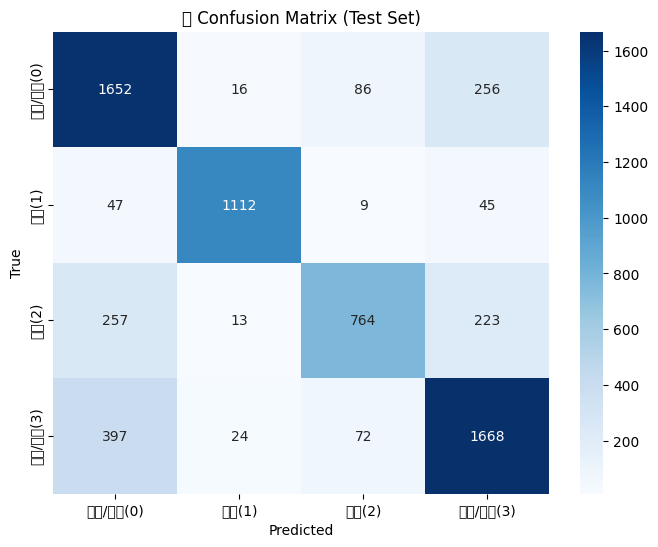

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ✅ Best 모델 로드
checkpoint = torch.load("/content/drive/MyDrive/Colab_Notebooks/Projects/NLP/models/best_model.pt", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()

# ✅ 테스트셋 준비
test_dataset = EmotionDataset(X_test, test_encoded_labels)
test_loader = DataLoader(test_dataset, batch_size=32)

# ✅ 예측 수행
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# ✅ 클래스 이름 직접 지정
target_names = ['슬픔/상처(0)', '기쁨(1)', '분노(2)', '불안/당황(3)']

# ✅ 성능 보고
print("최종 Test 결과:")
print(classification_report(all_labels, all_preds, target_names=target_names))

# ✅ Confusion Matrix 시각화
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()
